In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\County_Health_Rankings.csv")
df.head()

,State,County,State code,County code,Year span,Measure name,Measure id,Numerator,Denominator,Raw value,Confidence Interval Lower Bound,Confidence Interval Upper Bound,Data Release Year,fipscode
0,US,United States,0.0,0.0,2003-2005,Violent crime rate,43.0,1328750.667,274877117.0,483.398066,NaN,NaN,NaN,0.0
1,US,United States,0.0,0.0,2004-2006,Violent crime rate,43.0,1340928.667,277612778.5,483.021233,NaN,NaN,NaN,0.0
2,US,United States,0.0,0.0,2005-2007,Violent crime rate,43.0,1355853.167,280407694.7,483.529230,NaN,NaN,2010.0,0.0
3,US,United States,0.0,0.0,2006-2008,Violent crime rate,43.0,1366928.333,287614567.7,475.263942,NaN,NaN,2011.0,0.0
4,US,United States,0.0,0.0,2007-2009,Violent crime rate,43.0,1339439.333,292576281.2,457.808585,NaN,NaN,2012.0,0.0


In [14]:
# Basic cleaning
df.columns = df.columns.str.strip()

df = df.dropna(subset=['State','Raw value'])
df['Raw value'] = pd.to_numeric(df['Raw value'], errors='coerce')

state_df = df[df['State'] != 'US']


In [ ]:
#Average Violent Crime Rate bu State
state_crime = (state_df.groupby('State')['Raw value']
               .mean().
               sort_values()
)
top_10_states = state_crime.head(10)




<Axes: ylabel='State'>

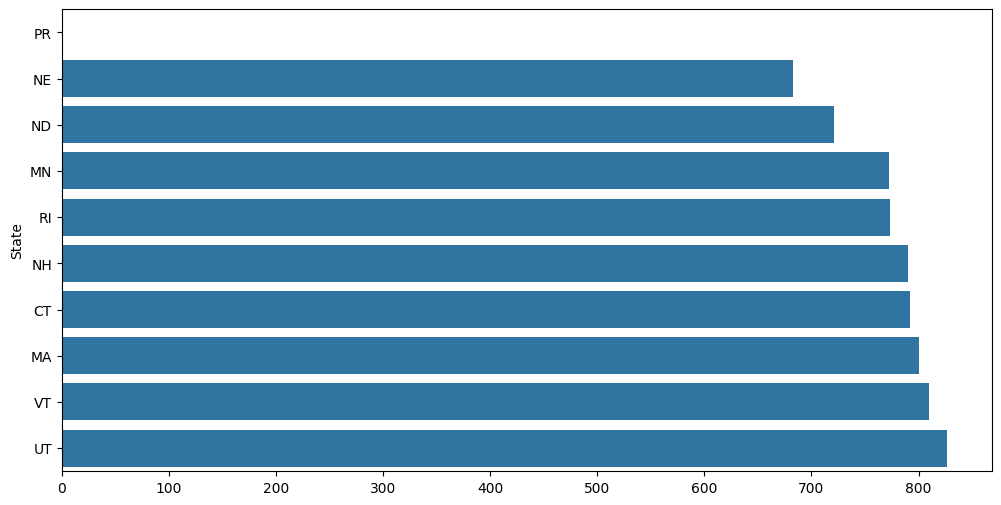

In [20]:
# Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)